# Регрессионный анализ: прогнозирование стоимости недвижимости  
## (Ridge Regression + XGBoost)

**Цель:**

1. Загрузить данные `all_v2.csv` о недвижимости в России за 2018–2021 гг.
2. Отфильтровать данные по региону `2661` — Санкт-Петербург и область.
3. Выполнить предварительную обработку данных:
   - удалить нетипичные объекты;
   - заменить некорректные значения количества комнат;
   - добавить новые признаки.
4. Провести анализ данных:
   - построить матрицу корреляции;
   - определить наиболее значимые признаки.
5. Закодировать категориальные признаки с помощью `Binary Encoder`.
6. Разделить данные на обучающую и тестовую выборки в пропорции 80/20.
7. Построить и обучить модели регрессии:
   - линейная регрессия с L2-регуляризацией `Ridge`;
   - модель градиентного бустинга `XGBoost`.
8. Оценить качество моделей с помощью метрик:
   - `RMSLE`;
   - `R²`;
   - `MAE`.
9. Сравнить результаты разных моделей.
10. Выполнить скоринг одного нового объекта недвижимости.

In [6]:
# 1. Импортируйте файл all_v2.csv, библиотеки sklearn, pandas, category_encoders, xgboost. Отфильтруйте 
#    по региону 2661 – Санкт-Петербург и область.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error
# Импорт BinaryEncoder для кодирования категориальных признаков
import category_encoders as ce
# Импорт модели XGBoost
from xgboost import XGBRegressor

df = pd.read_csv("all_v2.csv")
display(df.head())

# Информация о датасете: типы данных, количество непустых значений
df.info()
# Проверка размера исходного датасета
print("Размер исходного датасета:", df.shape)

# Фильтрация данных по региону 2661 — Санкт-Петербург и область
df = df[df["region"] == 2661].copy()

# Проверка размера датасета после фильтрации
print("Размер датасета после фильтрации по региону 2661:", df.shape)
display(df.head())

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 13 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           object 
 2   time           object 
 3   geo_lat        float64
 4   geo_lon        float64
 5   region         int64  
 6   building_type  int64  
 7   level          int64  
 8   levels         int64  
 9   rooms          int64  
 10  area           float64
 11  kitchen_area   float64
 12  object_type    int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 543.2+ MB
Размер исходного датасета: (5477006, 13)
Размер датасета после фильтрации по региону 2661: (461820, 13)


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
7,3600000,2018-03-04,20:52:38,59.875526,30.395457,2661,1,2,5,1,31.1,6.0,1
36,3200000,2018-04-10,16:10:12,59.827465,30.201827,2661,1,7,9,1,31.0,7.0,1
47,6500000,2018-04-23,11:47:58,59.988334,29.786928,2661,3,3,3,3,89.0,10.0,1
54,6300000,2018-04-28,17:47:24,59.911622,30.284556,2661,3,5,5,2,99.9,14.5,1


In [7]:
# 2. Оставьте только типовые объекты: S общ - 20-200 кв. м., S кухни 6-30 кв. м., Цена 1,5-50 млн.
print("Размер датасета до фильтрации типовых объектов:", df.shape)
df = df[
    (df["area"] >= 20) & (df["area"] <= 200) &
    (df["kitchen_area"] >= 6) & (df["kitchen_area"] <= 30) &
    (df["price"] >= 1_500_000) & (df["price"] <= 50_000_000)
].copy()

# Проверка размера датасета после фильтрации типовых объектов
print("Размер датасета после фильтрации типовых объектов:", df.shape)
display(df.head())

# Краткая статистика по основным числовым признакам
display(df[["price", "area", "kitchen_area"]].describe())

Размер датасета до фильтрации типовых объектов: (461820, 13)
Размер датасета после фильтрации типовых объектов: (410663, 13)


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
7,3600000,2018-03-04,20:52:38,59.875526,30.395457,2661,1,2,5,1,31.1,6.0,1
36,3200000,2018-04-10,16:10:12,59.827465,30.201827,2661,1,7,9,1,31.0,7.0,1
47,6500000,2018-04-23,11:47:58,59.988334,29.786928,2661,3,3,3,3,89.0,10.0,1
54,6300000,2018-04-28,17:47:24,59.911622,30.284556,2661,3,5,5,2,99.9,14.5,1


,price,area,kitchen_area
count,4.106630e+05,410663.000000,410663.000000
mean,7.595275e+06,57.528256,12.565677
std,5.075850e+06,24.991515,4.722221
min,1.500000e+06,20.000000,6.000000
25%,4.590000e+06,38.600000,9.100000
50%,6.065766e+06,52.000000,11.500000
75%,8.745887e+06,68.400000,15.100000
max,5.000000e+07,200.000000,30.000000


In [8]:
# 3. Число комнат «-1» и «-2» замените на 0.
print("Уникальные значения rooms до замены:")
print(sorted(df["rooms"].unique()))

print("\nКоличество объектов с rooms = -1:", (df["rooms"] == -1).sum())
print("Количество объектов с rooms = -2:", (df["rooms"] == -2).sum())

# Замена значений -1 и -2 на 0
# Такие значения интерпретируются как студии или специальные планировки
df["rooms"] = df["rooms"].replace({-1: 0, -2: 0})

# Проверка уникальных значений признака rooms после замены
print("\nУникальные значения rooms после замены:")
print(sorted(df["rooms"].unique()))

# Проверка количества объектов по числу комнат после замены
print("\nКоличество объектов по числу комнат после замены:")
print(df["rooms"].value_counts().sort_index())

Уникальные значения rooms до замены:
[-2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Количество объектов с rooms = -1: 5009
Количество объектов с rooms = -2: 18

Уникальные значения rooms после замены:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Количество объектов по числу комнат после замены:
rooms
0      5027
1    165509
2    140224
3     84028
4     12713
5      2545
6       426
7       124
8        42
9        25
Name: count, dtype: int64


In [9]:
# 4. Добавьте признаки: Этаж квартиры/Этажность, Первый, Последний этаж, ratio = (S кухни/S общая).
# Если число комнат 0, то ratio = S общая.
df["level_ratio"] = df["level"] / df["levels"]

# Добавление бинарного признака: находится ли квартира на первом этаже
# 1 — первый этаж, 0 — не первый этаж
df["is_first_floor"] = (df["level"] == 1).astype(int)

# Добавление бинарного признака: находится ли квартира на последнем этаже
# 1 — последний этаж, 0 — не последний этаж
df["is_last_floor"] = (df["level"] == df["levels"]).astype(int)

# Добавление признака: отношение площади кухни к общей площади квартиры
df["ratio"] = df["kitchen_area"] / df["area"]

# Для объектов с количеством комнат 0 значение ratio заменяется на общую площадь
df.loc[df["rooms"] == 0, "ratio"] = df.loc[df["rooms"] == 0, "area"]

# Проверка новых признаков
display(df[[
    "level", 
    "levels", 
    "level_ratio", 
    "is_first_floor", 
    "is_last_floor", 
    "rooms", 
    "area", 
    "kitchen_area", 
    "ratio"
]].head(10))

# Краткая статистика по новым признакам
display(df[[
    "level_ratio", 
    "is_first_floor", 
    "is_last_floor", 
    "ratio"
]].describe())

# Проверка количества квартир на первом и последнем этажах
print("Количество объектов на первом этаже:")
print(df["is_first_floor"].value_counts())

print("\nКоличество объектов на последнем этаже:")
print(df["is_last_floor"].value_counts())

,level,levels,level_ratio,is_first_floor,is_last_floor,rooms,area,kitchen_area,ratio
0,8,10,0.800000,0,0,3,82.6,10.8,0.130751
7,2,5,0.400000,0,0,1,31.1,6.0,0.192926
36,7,9,0.777778,0,0,1,31.0,7.0,0.225806
47,3,3,1.000000,0,1,3,89.0,10.0,0.112360
54,5,5,1.000000,0,1,2,99.9,14.5,0.145145
66,7,12,0.583333,0,0,3,69.0,11.0,0.159420
69,14,14,1.000000,0,1,2,60.0,11.0,0.183333
76,2,17,0.117647,0,0,1,44.9,16.5,0.367483
98,3,4,0.750000,0,0,2,52.6,8.8,0.167300
106,1,6,0.166667,1,0,3,68.0,8.3,0.122059


,level_ratio,is_first_floor,is_last_floor,ratio
count,410663.000000,410663.000000,410663.000000,410663.000000
mean,0.541709,0.063865,0.085942,0.619171
std,0.282340,0.244513,0.280278,3.828430
min,0.032258,0.000000,0.000000,0.033021
25%,0.300000,0.000000,0.000000,0.166667
50%,0.538462,0.000000,0.000000,0.229032
75%,0.782609,0.000000,0.000000,0.292335
max,4.000000,1.000000,1.000000,195.800000


Количество объектов на первом этаже:
is_first_floor
0    384436
1     26227
Name: count, dtype: int64

Количество объектов на последнем этаже:
is_last_floor
0    375370
1     35293
Name: count, dtype: int64


In [10]:
# 5. Добавьте признак Давность объявления. В качестве даты отсчета используйте дату
df["date"] = pd.to_datetime(df["date"])

# Проверка минимальной и максимальной даты объявления
print("Минимальная дата объявления:", df["date"].min())
print("Максимальная дата объявления:", df["date"].max())

# В качестве даты отсчета используем максимальную дату в датасете
reference_date = df["date"].max()

print("Дата отсчета:", reference_date)

# Добавление признака давности объявления в днях
df["ad_age"] = (reference_date - df["date"]).dt.days

display(df[["date", "ad_age"]].head(10))
# Краткая статистика по новому признаку
display(df["ad_age"].describe())

Минимальная дата объявления: 2018-02-19 00:00:00
Максимальная дата объявления: 2021-05-01 00:00:00
Дата отсчета: 2021-05-01 00:00:00


,date,ad_age
0,2018-02-19,1167
7,2018-03-04,1154
36,2018-04-10,1117
47,2018-04-23,1104
54,2018-04-28,1099
66,2018-05-22,1075
69,2018-05-26,1071
76,2018-06-02,1064
98,2018-06-29,1037
106,2018-07-04,1032


count    410663.000000
mean        470.672763
std         277.338364
min           0.000000
25%         252.000000
50%         441.000000
75%         698.000000
max        1167.000000
Name: ad_age, dtype: float64

Корреляция признаков с price:


price             1.000000
area              0.780188
rooms             0.524654
kitchen_area      0.490240
building_type     0.076815
level_ratio       0.073884
geo_lat           0.059786
is_last_floor     0.037881
object_type      -0.021540
ratio            -0.051590
is_first_floor   -0.060652
geo_lon          -0.069051
level            -0.076799
ad_age           -0.146865
levels           -0.177535
region                 NaN
Name: price, dtype: float64

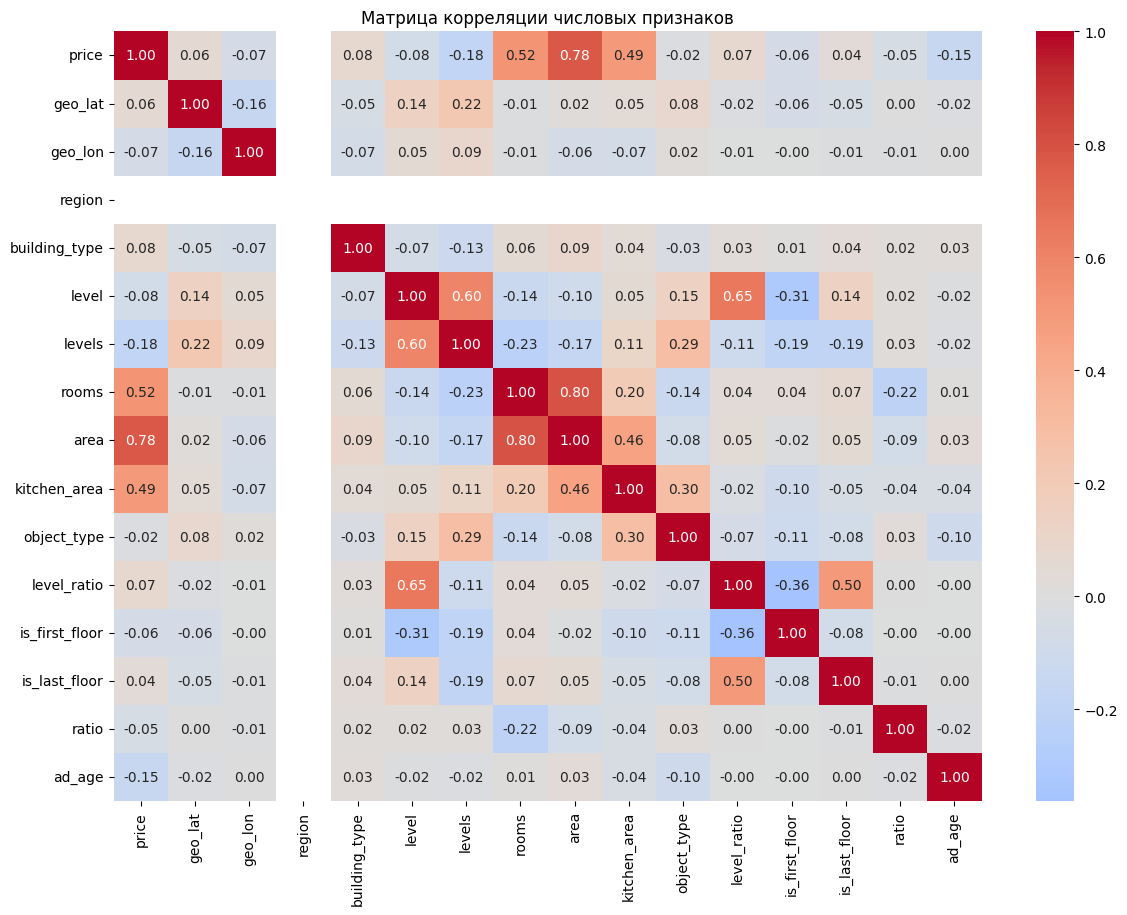

In [11]:
# 6. Постройте матрицу корреляции (pandas.corr()).
import matplotlib.pyplot as plt
import seaborn as sns

# Построение матрицы корреляции только для числовых признаков
corr_matrix = df.corr(numeric_only=True)

# Вывод корреляции признаков с целевой переменной price
price_corr = corr_matrix["price"].sort_values(ascending=False)

print("Корреляция признаков с price:")
display(price_corr)

# Визуализация матрицы корреляции
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Матрица корреляции числовых признаков")
plt.show()

Признак `region` после фильтрации принимает только одно значение — `2661`.  
Поэтому его корреляция с другими признаками не рассчитывается и отображается как `NaN`.


In [12]:
# 7. Закодируйте категориальные признаки (Binary Encoder из category_encoders)
y = df["price"]

# Создание матрицы признаков
# Удаляем price, так как это целевая переменная
# Удаляем date и time, так как дата уже представлена признаком ad_age
# Удаляем region, так как после фильтрации это константный признак
X = df.drop(columns=["price", "date", "time", "region"])

# Определение категориальных признаков для кодирования
categorical_cols = ["building_type", "object_type"]

# Проверка размера данных до кодирования
print("Размер X до кодирования:", X.shape)

# Проверка уникальных значений категориальных признаков
print("\nУникальные значения building_type:")
print(sorted(X["building_type"].unique()))

print("\nУникальные значения object_type:")
print(sorted(X["object_type"].unique()))

# Создание Binary Encoder
encoder = ce.BinaryEncoder(cols=categorical_cols)

# Кодирование категориальных признаков
X_encoded = encoder.fit_transform(X)

# Проверка размера данных после кодирования
print("\nРазмер X после кодирования:", X_encoded.shape)

# Просмотр первых строк после кодирования
display(X_encoded.head())

# Просмотр списка признаков после кодирования
print("\nСписок признаков после кодирования:")
print(X_encoded.columns.tolist())

Размер X до кодирования: (410663, 14)

Уникальные значения building_type:
[0, 1, 2, 3, 4, 5]

Уникальные значения object_type:
[1, 11]

Размер X после кодирования: (410663, 17)


,geo_lat,geo_lon,building_type_0,building_type_1,building_type_2,level,levels,rooms,area,kitchen_area,object_type_0,object_type_1,level_ratio,is_first_floor,is_last_floor,ratio,ad_age
0,59.805808,30.376141,0,0,1,8,10,3,82.6,10.8,0,1,0.800000,0,0,0.130751,1167
7,59.875526,30.395457,0,0,1,2,5,1,31.1,6.0,0,1,0.400000,0,0,0.192926,1154
36,59.827465,30.201827,0,0,1,7,9,1,31.0,7.0,0,1,0.777778,0,0,0.225806,1117
47,59.988334,29.786928,0,1,0,3,3,3,89.0,10.0,0,1,1.000000,0,1,0.112360,1104
54,59.911622,30.284556,0,1,0,5,5,2,99.9,14.5,0,1,1.000000,0,1,0.145145,1099



Список признаков после кодирования:
['geo_lat', 'geo_lon', 'building_type_0', 'building_type_1', 'building_type_2', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type_0', 'object_type_1', 'level_ratio', 'is_first_floor', 'is_last_floor', 'ratio', 'ad_age']


In [13]:
# 8. Разбейте на обучающее и тестовое множества в пропорции 80/20, random_seed = 42.
from sklearn.model_selection import train_test_split

# Разбиение данных на обучающую и тестовую выборки
# 80% — обучение, 20% — тест
# random_state=42 обеспечивает воспроизводимость результата
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Проверка размеров полученных выборок
print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

# Проверка долей
print("\nДоля обучающей выборки:", round(len(X_train) / len(X_encoded), 2))
print("Доля тестовой выборки:", round(len(X_test) / len(X_encoded), 2))

Размер X_train: (328530, 17)
Размер X_test: (82133, 17)
Размер y_train: (328530,)
Размер y_test: (82133,)

Доля обучающей выборки: 0.8
Доля тестовой выборки: 0.2


In [ ]:
# 9.1 Стандартизируйте числовые признаки и постройте модель линейной регрессии с L2-регуляризацией (sklearn.linear_model.Ridge)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Создание копий данных для Ridge-модели
X_train_ridge = X_train.copy()
X_test_ridge = X_test.copy()

# Числовые признаки, которые нужно стандартизировать
# Бинарные признаки после кодирования и признаки 0/1 стандартизировать не обязательно
numeric_cols = [
    "geo_lat",
    "geo_lon",
    "level",
    "levels",
    "rooms",
    "area",
    "kitchen_area",
    "level_ratio",
    "ratio",
    "ad_age"
]

# Создание StandardScaler
scaler = StandardScaler()

# Обучаем scaler только на обучающей выборке
X_train_ridge[numeric_cols] = scaler.fit_transform(X_train_ridge[numeric_cols])

# Тестовую выборку только трансформируем
X_test_ridge[numeric_cols] = scaler.transform(X_test_ridge[numeric_cols])

# Создание модели Ridge-регрессии с L2-регуляризацией
ridge_model = Ridge(alpha=1.0, random_state=42)

# Обучение модели
ridge_model.fit(X_train_ridge, y_train)

# Предсказание на тестовой выборке
y_pred_ridge = ridge_model.predict(X_test_ridge)

# Оценка качества модели
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression results:")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Ridge Regression results:
MAE: 1708560.4166013137
RMSE: 2823925.337689004
R2: 0.6939830554538402


In [15]:
# 9.2 Постройте модель XGBoost (стандартизировать необязательно).
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Создание модели XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# Обучение модели
xgb_model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_xgb = xgb_model.predict(X_test)

# Оценка качества модели
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost results:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost results:
MAE: 897258.5528898251
RMSE: 1666901.820165723
R2: 0.8933749872908496


Ridge Regression metrics:
Train RMSLE: 0.5241029237945621
Test RMSLE: 0.5241378820959475
Train R2: 0.6949354378901861
Test R2: 0.6939830554538402
Train MAE: 1692792.5637397172
Test MAE: 1708560.4166013137

XGBoost metrics:
Train RMSLE: 0.16416789978687188
Test RMSLE: 0.17034349232548254
Train R2: 0.9071073290028758
Test R2: 0.8933749872908496
Train MAE: 858813.2167283049
Test MAE: 897258.5528898251


,Model,Dataset,RMSLE,R2,MAE
0,Ridge,Train,0.524103,0.694935,1.692793e+06
1,Ridge,Test,0.524138,0.693983,1.708560e+06
2,XGBoost,Train,0.164168,0.907107,8.588132e+05
3,XGBoost,Test,0.170343,0.893375,8.972586e+05


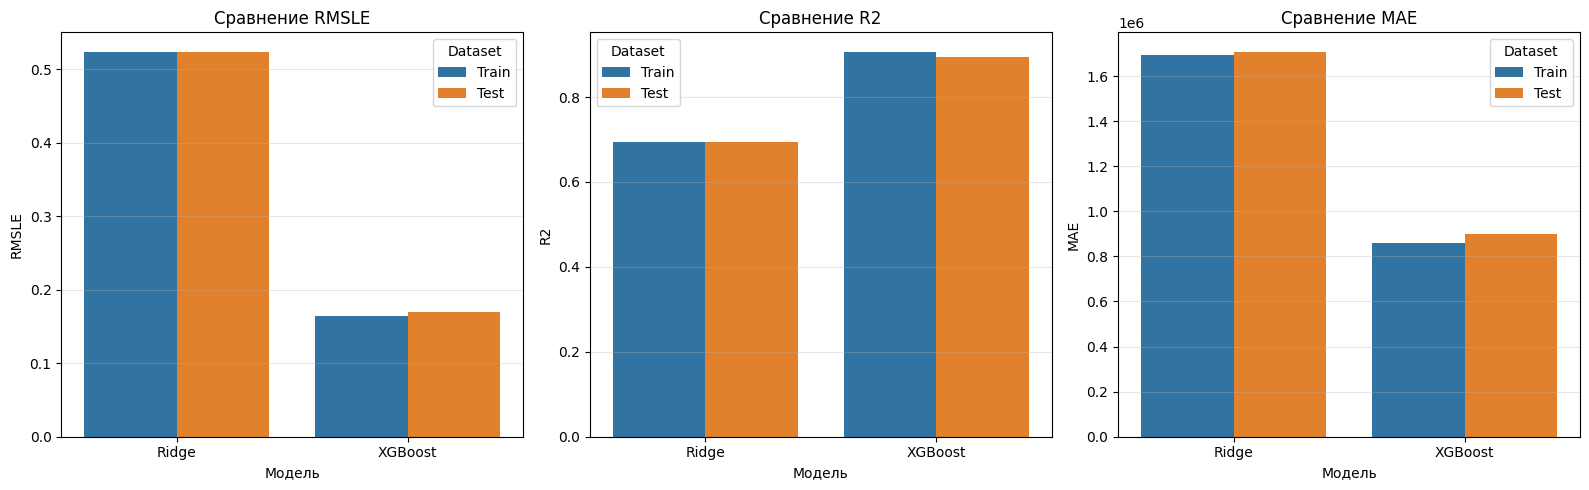

In [17]:
# 10. Рассчитайте регрессионные метрики RMSLE, R2, MAE
# для обучающей и тестовой выборок (sklearn.metrics)

from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    # RMSLE нельзя считать для отрицательных предсказаний,
    # поэтому заменяем отрицательные значения на 0
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


# =====================================================
# Метрики для Ridge Regression
# =====================================================

# Предсказания Ridge на обучающей выборке
y_train_pred_ridge = ridge_model.predict(X_train_ridge)

# Предсказания Ridge на тестовой выборке
y_test_pred_ridge = ridge_model.predict(X_test_ridge)

# Расчет метрик Ridge
ridge_train_rmsle = rmsle(y_train, y_train_pred_ridge)
ridge_test_rmsle = rmsle(y_test, y_test_pred_ridge)

ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)

ridge_train_mae = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)


# =====================================================
# Метрики для XGBoost
# =====================================================

# Предсказания XGBoost на обучающей выборке
y_train_pred_xgb = xgb_model.predict(X_train)

# Предсказания XGBoost на тестовой выборке
y_test_pred_xgb = xgb_model.predict(X_test)

# Расчет метрик XGBoost
xgb_train_rmsle = rmsle(y_train, y_train_pred_xgb)
xgb_test_rmsle = rmsle(y_test, y_test_pred_xgb)

xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)

xgb_train_mae = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)


# =====================================================
# Вывод результатов
# =====================================================

print("Ridge Regression metrics:")
print("Train RMSLE:", ridge_train_rmsle)
print("Test RMSLE:", ridge_test_rmsle)
print("Train R2:", ridge_train_r2)
print("Test R2:", ridge_test_r2)
print("Train MAE:", ridge_train_mae)
print("Test MAE:", ridge_test_mae)

print("\nXGBoost metrics:")
print("Train RMSLE:", xgb_train_rmsle)
print("Test RMSLE:", xgb_test_rmsle)
print("Train R2:", xgb_train_r2)
print("Test R2:", xgb_test_r2)
print("Train MAE:", xgb_train_mae)
print("Test MAE:", xgb_test_mae)


# =====================================================
# Сравнительная таблица
# =====================================================

results = pd.DataFrame({
    "Model": ["Ridge", "Ridge", "XGBoost", "XGBoost"],
    "Dataset": ["Train", "Test", "Train", "Test"],
    "RMSLE": [
        ridge_train_rmsle,
        ridge_test_rmsle,
        xgb_train_rmsle,
        xgb_test_rmsle
    ],
    "R2": [
        ridge_train_r2,
        ridge_test_r2,
        xgb_train_r2,
        xgb_test_r2
    ],
    "MAE": [
        ridge_train_mae,
        ridge_test_mae,
        xgb_train_mae,
        xgb_test_mae
    ]
})

display(results)


# =====================================================
# Визуализация метрик
# =====================================================

plt.figure(figsize=(16, 5))

# RMSLE
plt.subplot(1, 3, 1)
sns.barplot(data=results, x="Model", y="RMSLE", hue="Dataset")
plt.title("Сравнение RMSLE")
plt.ylabel("RMSLE")
plt.xlabel("Модель")
plt.grid(axis="y", alpha=0.3)

# R2
plt.subplot(1, 3, 2)
sns.barplot(data=results, x="Model", y="R2", hue="Dataset")
plt.title("Сравнение R2")
plt.ylabel("R2")
plt.xlabel("Модель")
plt.grid(axis="y", alpha=0.3)

# MAE
plt.subplot(1, 3, 3)
sns.barplot(data=results, x="Model", y="MAE", hue="Dataset")
plt.title("Сравнение MAE")
plt.ylabel("MAE")
plt.xlabel("Модель")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# 11. Сравните результаты от разных моделей.
# Расчет улучшения XGBoost относительно Ridge на тестовой выборке

mae_improvement = (ridge_test_mae - xgb_test_mae) / ridge_test_mae * 100
rmsle_improvement = (ridge_test_rmsle - xgb_test_rmsle) / ridge_test_rmsle * 100
r2_improvement = (xgb_test_r2 - ridge_test_r2) / ridge_test_r2 * 100

print("Улучшение XGBoost относительно Ridge на тестовой выборке:")
print("MAE improvement:", round(mae_improvement, 2), "%")
print("RMSLE improvement:", round(rmsle_improvement, 2), "%")
print("R2 improvement:", round(r2_improvement, 2), "%")

Улучшение XGBoost относительно Ridge на тестовой выборке:
MAE improvement: 47.48 %
RMSLE improvement: 67.5 %
R2 improvement: 28.73 %


,feature,importance
0,area,0.474105
1,levels,0.063783
2,ad_age,0.061270
3,rooms,0.060729
4,building_type_2,0.053315
5,kitchen_area,0.050676
6,geo_lat,0.040192
7,building_type_1,0.034573
8,building_type_0,0.026160
9,ratio,0.026037


C:\Users\Administrator\AppData\Local\Temp\ipykernel_22840\3089515598.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


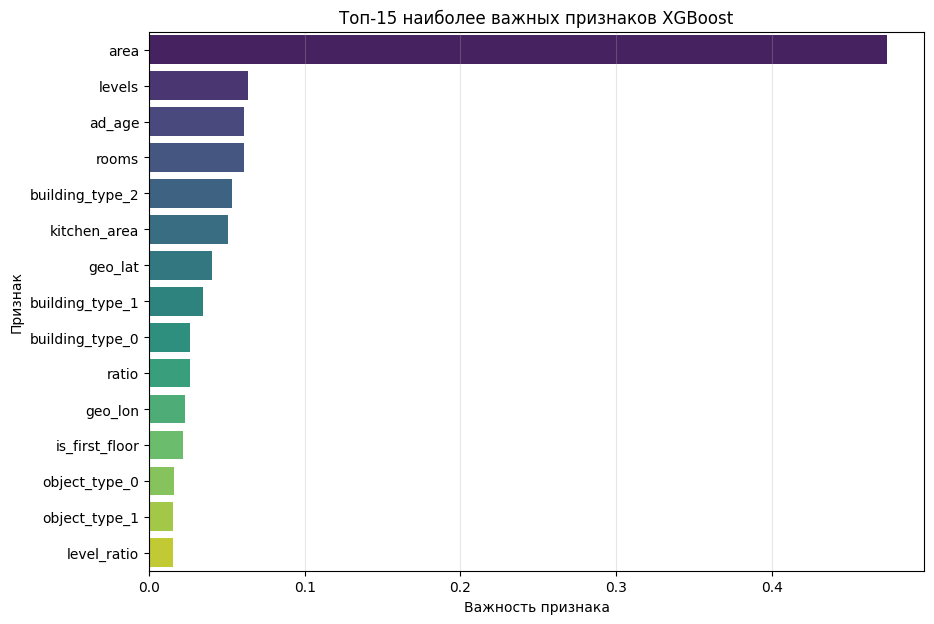

In [19]:
# 12. Посмотрите свойство feature_importances_ и проведите анализ значимых признаков

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Получение важности признаков из модели XGBoost
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

# Сортировка признаков по важности
feature_importances = feature_importances.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Вывод таблицы важности признаков
display(feature_importances)

# Топ-15 наиболее важных признаков
top_features = feature_importances.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Топ-15 наиболее важных признаков XGBoost")
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 13. Обсуждение «подводных камней» признака `Давность объявления`

Признак `ad_age` показывает давность объявления, то есть сколько времени прошло с момента его публикации.

С одной стороны, этот признак может быть полезным. Он может отражать ликвидность объекта и уровень спроса. Например, если квартира долго находится в продаже, это может означать, что цена завышена, у объекта есть недостатки или спрос на него ниже.

С другой стороны, у этого признака есть важный риск — возможная утечка данных.

Если модель используется для прогнозирования цены нового объявления в момент его публикации, то `ad_age` в этот момент либо недоступен, либо равен 0. Поэтому при обучении модель может использовать информацию, которой в реальной ситуации прогнозирования еще не будет.

Иными словами, модель как будто получает информацию из будущего: она знает, сколько времени объявление уже находится на рынке, хотя для нового объявления это заранее неизвестно.

Также объявления с большой давностью могут отличаться от новых объявлений. Например, долго висящие объявления часто могут иметь завышенную цену, низкий спрос или специфические характеристики. Из-за этого модель может выучить зависимость между давностью объявления и ценой, которая не всегда будет корректно работать на новых данных.

Поэтому важно учитывать сценарий использования модели:

- если модель оценивает уже существующие объявления, признак `ad_age` можно использовать, но с осторожностью;
- если модель должна прогнозировать цену нового объявления, лучше не использовать `ad_age`, так как в реальном прогнозе этот признак будет недоступен или будет равен 0.

Чтобы проверить, насколько этот признак действительно нужен, стоит сравнить качество модели с `ad_age` и без него. Если после удаления `ad_age` качество модели почти не ухудшается, лучше исключить этот признак. Это сделает модель более устойчивой, честной и пригодной для практического использования.

Итог: `ad_age` — полезный, но рискованный признак. Он может отражать ликвидность объекта и рыночный спрос, но при прогнозировании цены нового объявления может привести к утечке данных. Поэтому его использование нужно отдельно проверять и обосновывать.

In [21]:
# 14. Сделайте скоринг одного нового объекта
# Скоринг квартиры в регионе 2661 — Санкт-Петербург и област
# Создание нового объекта недвижимости
# Пример квартиры в Санкт-Петербурге

new_flat = pd.DataFrame([{
    "area": 45,
    "rooms": 2,
    "kitchen_area": 8,
    "level": 5,
    "levels": 9,
    "geo_lat": 59.9343,
    "geo_lon": 30.3351,
    "ad_age": 10,
    "ratio": 8 / 45,
    "level_ratio": 5 / 9,
    "is_first_floor": 0,

    # One-hot признаки типа здания
    "building_type_0": 0,
    "building_type_1": 1,
    "building_type_2": 0,
    "building_type_3": 0,
    "building_type_4": 0,
    "building_type_5": 0,

    # One-hot признаки типа объекта
    "object_type_0": 1,
    "object_type_1": 0,
    "object_type_2": 0
}])

# Приведение нового объекта к структуре обучающей выборки
new_flat = new_flat.reindex(columns=X_train.columns, fill_value=0)

display(new_flat)

# Прогноз цены с помощью лучшей модели XGBoost
predicted_price_xgb = xgb_model.predict(new_flat)

print("Прогнозируемая стоимость квартиры по модели XGBoost:")
print(round(predicted_price_xgb[0], 2), "руб.")

,geo_lat,geo_lon,building_type_0,building_type_1,building_type_2,level,levels,rooms,area,kitchen_area,object_type_0,object_type_1,level_ratio,is_first_floor,is_last_floor,ratio,ad_age
0,59.9343,30.3351,0,1,0,5,9,2,45,8,1,0,0.555556,0,0,0.177778,10


Прогнозируемая стоимость квартиры по модели XGBoost:
10487925.0 руб.


## вывод

В ходе работы была построена модель для прогнозирования стоимости недвижимости в регионе `2661 — Санкт-Петербург и область`.

Сначала данные были отфильтрованы: были оставлены только типовые объекты с общей площадью от 20 до 200 кв. м, площадью кухни от 6 до 30 кв. м и ценой от 1,5 до 50 млн руб. Также были обработаны некорректные значения количества комнат: значения `-1` и `-2` были заменены на `0`.

После этого были добавлены новые признаки:

- отношение этажа квартиры к общей этажности дома;
- признак первого этажа;
- признак последнего этажа;
- отношение площади кухни к общей площади;
- давность объявления `ad_age`.

Категориальные признаки были закодированы, а данные разделены на обучающую и тестовую выборки в пропорции 80/20.

Для прогнозирования были построены две модели:

- Ridge Regression;
- XGBoost Regressor.

По результатам сравнения XGBoost показал себя значительно лучше Ridge Regression на тестовой выборке:

- улучшение по MAE: **47.48%**;
- улучшение по RMSLE: **67.5%**;
- улучшение по R²: **28.73%**.

Это говорит о том, что XGBoost лучше справляется с данной задачей, так как он умеет учитывать нелинейные зависимости между признаками. Для недвижимости это особенно важно, потому что цена зависит не только от площади, но и от сочетания разных факторов: расположения, этажности, типа дома, количества комнат и других характеристик.

Анализ важности признаков показал, что самым значимым признаком является `area`, то есть общая площадь квартиры. Это логично, так как площадь напрямую влияет на стоимость объекта. Также важными оказались признаки `levels`, `ad_age`, `rooms`, `building_type`, `kitchen_area`, `geo_lat` и `geo_lon`.

Отдельно был рассмотрен признак `ad_age`, который показывает давность объявления. Он оказался достаточно важным для модели, но при этом его нужно использовать осторожно. С одной стороны, он может отражать ликвидность объекта и спрос на рынке. С другой стороны, если модель используется для оценки нового объявления в момент публикации, этот признак может быть недоступен или равен нулю. Поэтому `ad_age` может привести к утечке данных, и его использование зависит от реального сценария применения модели.

Также был выполнен скоринг одного нового объекта. Так как исходные данные были отфильтрованы по Санкт-Петербургу и области, для нового объекта корректно использовать координаты именно этого региона, а не Москвы. Для оценки была использована лучшая модель — XGBoost.

В целом можно сделать вывод, что модель XGBoost хорошо подходит для решения задачи прогнозирования стоимости недвижимости в Санкт-Петербурге и области. Она показывает более высокое качество по сравнению с линейной моделью Ridge и лучше учитывает сложные зависимости в данных. При этом для практического применения модели важно внимательно относиться к признакам, которые могут быть недоступны в момент реального прогноза, особенно к признаку `ad_age`.